In [1]:
library(tidyverse)
library(ggrepel)

── Attaching core tidyverse packages ─────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ───────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
mva <- read_csv("./deseq2_mockAuxResc_results_36/GFP_raw_counts.csv_aux_v_mock_results.csv")
rva <- read_csv("./deseq2_mockAuxResc_results_36/GFP_raw_counts.csv_resc_v_aux_results.csv")
PAT <- 0.005
FCT <- 1.5

Rows: 6406 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): V1, directionality
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, padj
lgl (1): Significative

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 6406 Columns: 9
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (2): V1, directionality
dbl (6): baseMean, log2FoldChange, lfcSE, stat, pvalue, padj
lgl (1): Significative

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
sigboth <- mva$Significative == TRUE & rva$Significative == TRUE
table(sigboth)

sigboth
FALSE  TRUE 
 5306  1100 

In [4]:
dplot <- function(ft)
{
    f1 <- ft |> mutate(db = case_when(Significative == TRUE & directionality == "UP" ~ 'Up',
                                      Significative == TRUE & directionality == "DOWN" ~ "Down",
                                      .default = 'Unchanged'))
    f1$db <- as.factor(f1$db)
    f1$all <- "all"
    
    print(paste("Differentially Binding over Peaks |log2(FoldChange)| > 1.5 and q-Value < 0.001"))
    print(table(f1$db))
    print("---------------------------------------------------------------------")
    print(paste("DISTRIBUCION DE ADJUSTED P"))
    print(quantile(f1$padj, na.rm = T))
    print("---------------------------------------------------------------------")
    print(paste("DISTRIBUCION DE Log2FC ABSOLUTO"))
    print(quantile(abs(f1$log2FoldChange), na.rm = T))
    print("---------------------------------------------------------------------")
    print(ggplot (f1, aes(x= abs(log2FoldChange) ,y = all )) + geom_violin())
  
    print(ggplot (f1, aes(x= log2FoldChange ,y = all )) + geom_violin())
   
    print(ggplot (f1, aes(x= padj ,y = all )) + geom_violin())
   
    print(ggplot (f1, aes(x= log2FoldChange , color = db)) + geom_density())
   
    print(ggplot (f1, aes (y= -log2(padj), x = log2FoldChange, color = db)) + geom_point())
  

    f1$all <- NULL
    return(f1)
}

dthrexploration <- function (fg, patlad = c(0.001, 0.005, 0.01, 0.05), fctlad = c(2,1.5,1,0.5))
{
    dbrByFilter <- c()

    for (fp in fctlad){
        for (pp in patlad){
            ft <- fg |> mutate(db = case_when(abs(log2FoldChange) > fp & padj < pp ~ 'DBR' ,.default = 'Unchanged')) |> filter(db == 'DBR')
            todf <- c(fp,pp,nrow(ft),nrow(filter(ft,log2FoldChange > 0))/nrow(ft))
            dbrByFilter <- rbind(dbrByFilter, todf)
        }
    }
    colnames(dbrByFilter) <- c("log2FoldChange","padj","dbr_total","dbr_positive_fraction")
    return(dbrByFilter)
}

,log2FoldChange,padj,dbr_total,dbr_positive_fraction
todf,2.0,0.001,695,1.0000000
todf,2.0,0.005,726,1.0000000
todf,2.0,0.010,731,1.0000000
todf,2.0,0.050,754,0.9986737
todf,1.5,0.001,953,1.0000000
todf,1.5,0.005,1102,1.0000000
todf,1.5,0.010,1161,1.0000000
todf,1.5,0.050,1305,0.9969349
todf,1.0,0.001,972,1.0000000
todf,1.0,0.005,1193,1.0000000


[1] "Differentially Binding over Peaks |log2(FoldChange)| > 1.5 and q-Value < 0.001"

Unchanged        Up 
     5304      1102 
[1] "---------------------------------------------------------------------"
[1] "DISTRIBUCION DE ADJUSTED P"
          0%          25%          50%          75%         100% 
5.949181e-36 2.843241e-02 4.421678e-01 7.889028e-01 9.999962e-01 
[1] "---------------------------------------------------------------------"
[1] "DISTRIBUCION DE Log2FC ABSOLUTO"
          0%          25%          50%          75%         100% 
2.340101e-06 2.789455e-01 6.775147e-01 1.351599e+00 4.893491e+00 
[1] "---------------------------------------------------------------------"


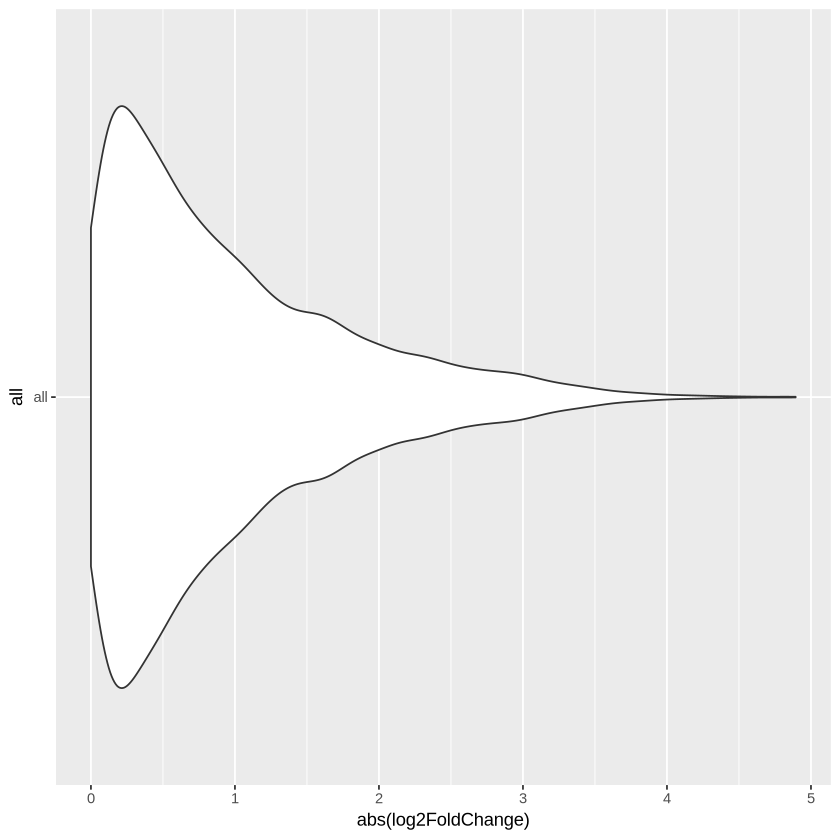

Warning message:
“Removed 249 rows containing non-finite outside the scale range (`stat_ydensity()`).”


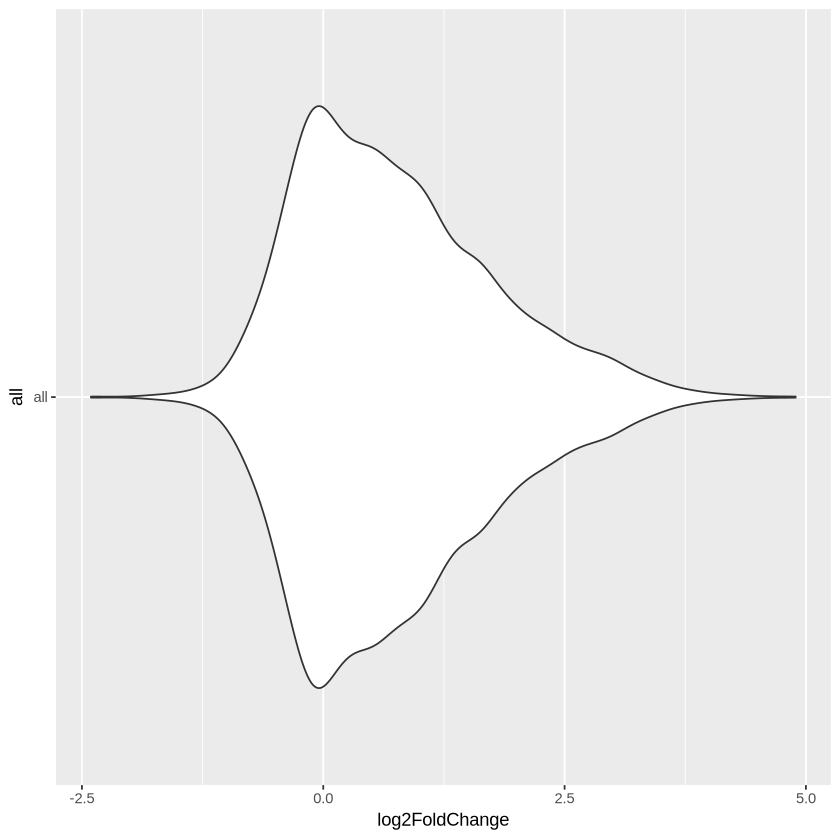

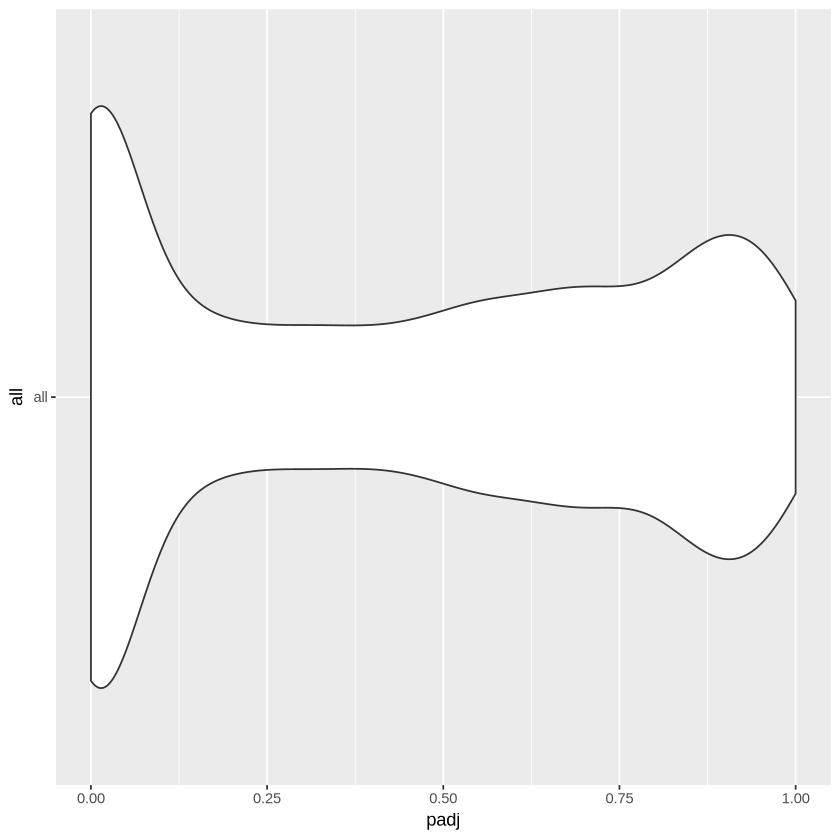

Warning message:
“Removed 249 rows containing missing values or values outside the scale range (`geom_point()`).”


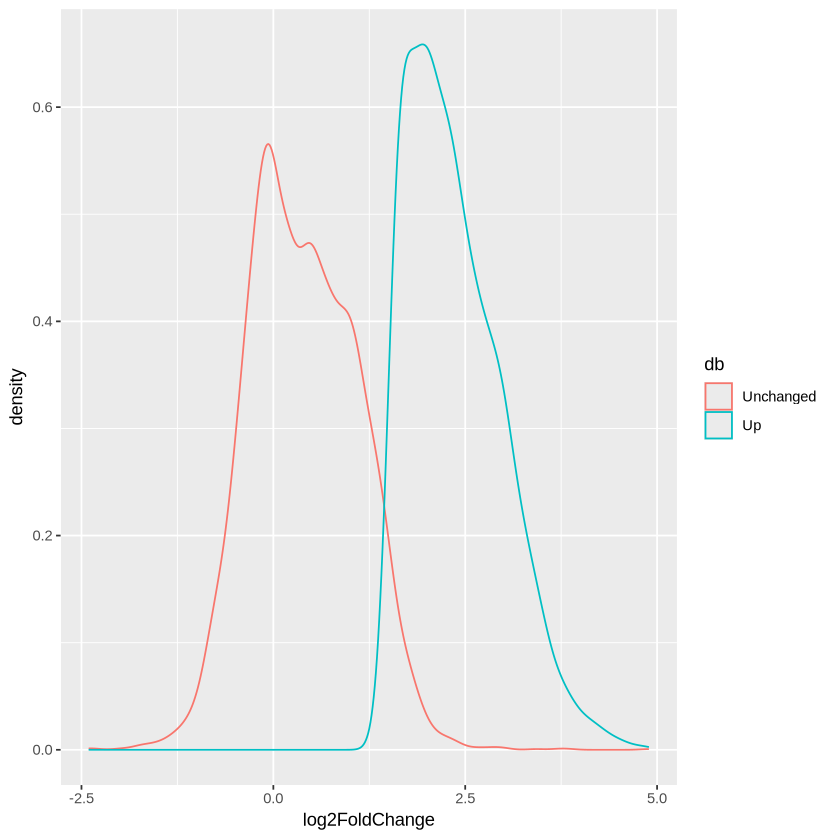

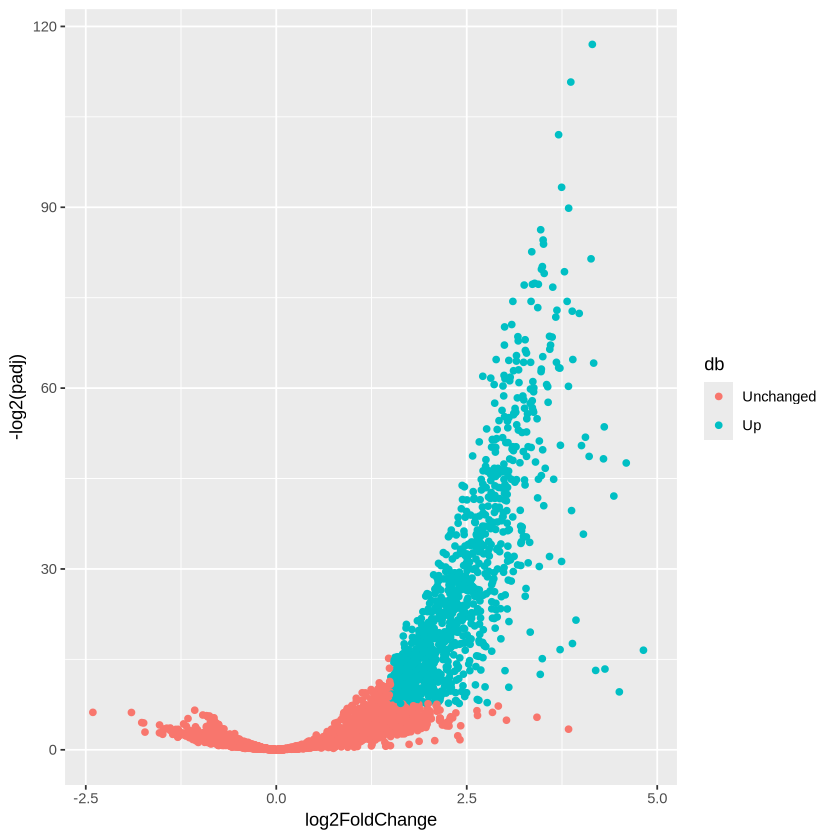

In [5]:
dthrexploration(rva)
rva <- dplot(rva)

,log2FoldChange,padj,dbr_total,dbr_positive_fraction
todf,2.0,0.001,2880,0.0000000000
todf,2.0,0.005,3074,0.0003253090
todf,2.0,0.010,3125,0.0003200000
todf,2.0,0.050,3178,0.0006293266
todf,1.5,0.001,3111,0.0000000000
todf,1.5,0.005,3489,0.0005732302
todf,1.5,0.010,3650,0.0008219178
todf,1.5,0.050,3943,0.0020289120
todf,1.0,0.001,3117,0.0000000000
todf,1.0,0.005,3515,0.0005689900


[1] "Differentially Binding over Peaks |log2(FoldChange)| > 1.5 and q-Value < 0.001"

     Down Unchanged        Up 
     3487      2917         2 
[1] "---------------------------------------------------------------------"
[1] "DISTRIBUCION DE ADJUSTED P"
          0%          25%          50%          75%         100% 
1.471233e-39 6.023597e-08 1.438378e-03 2.665688e-01 9.999870e-01 
[1] "---------------------------------------------------------------------"
[1] "DISTRIBUCION DE Log2FC ABSOLUTO"
          0%          25%          50%          75%         100% 
8.004420e-06 6.238501e-01 1.993070e+00 2.734064e+00 6.884761e+00 
[1] "---------------------------------------------------------------------"


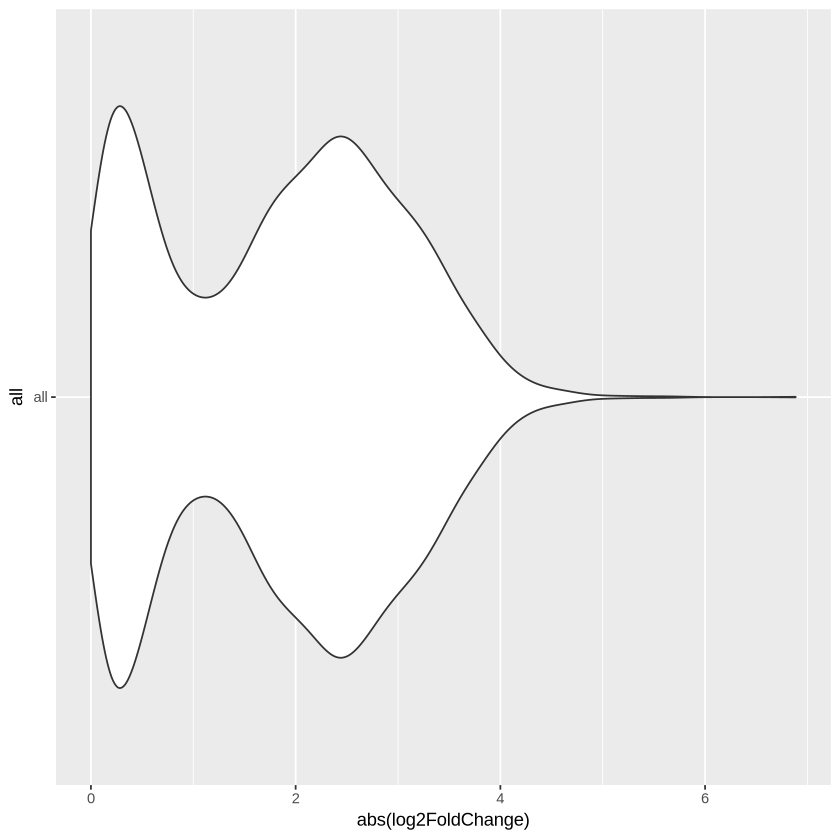

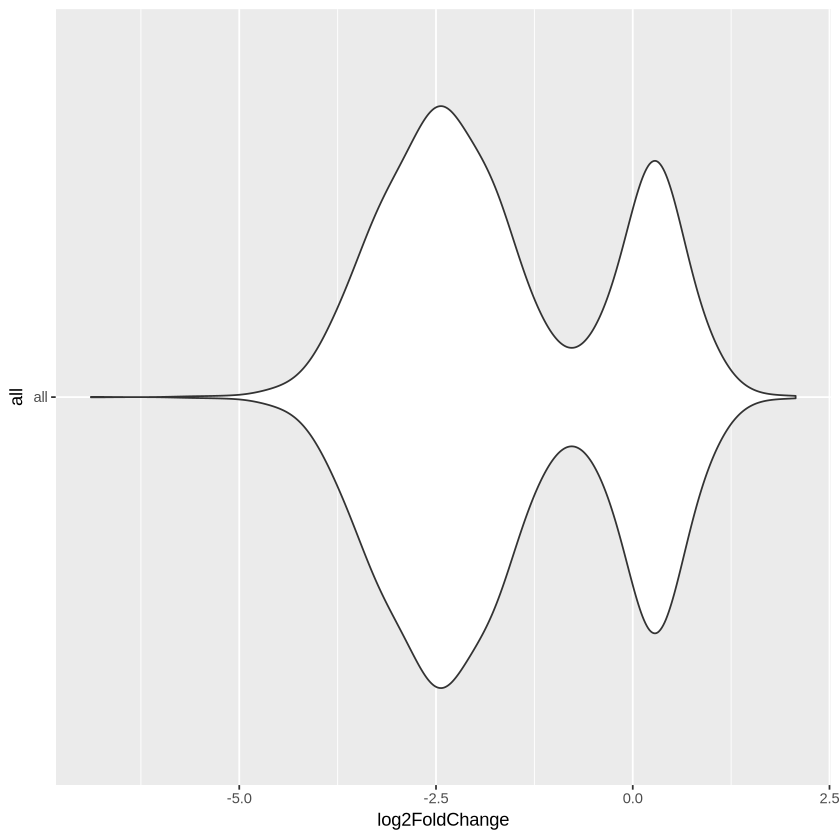

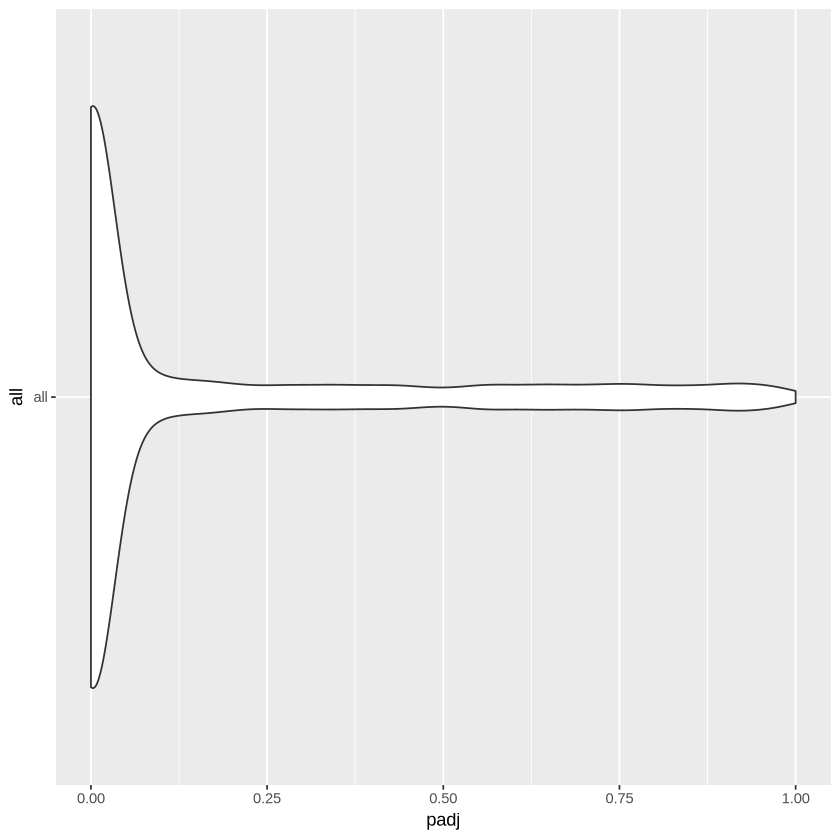

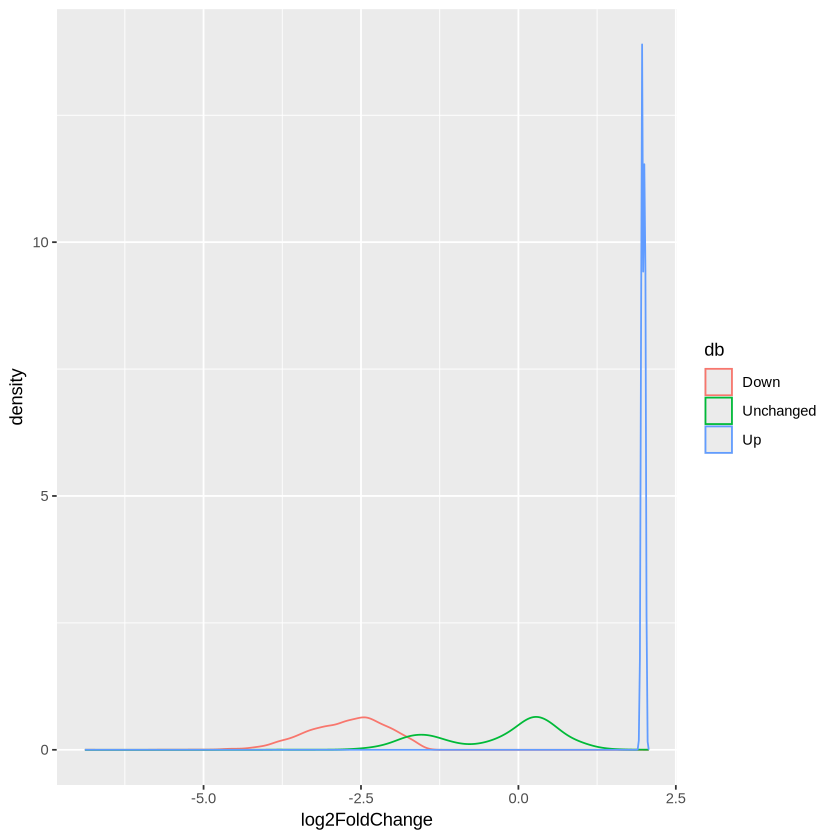

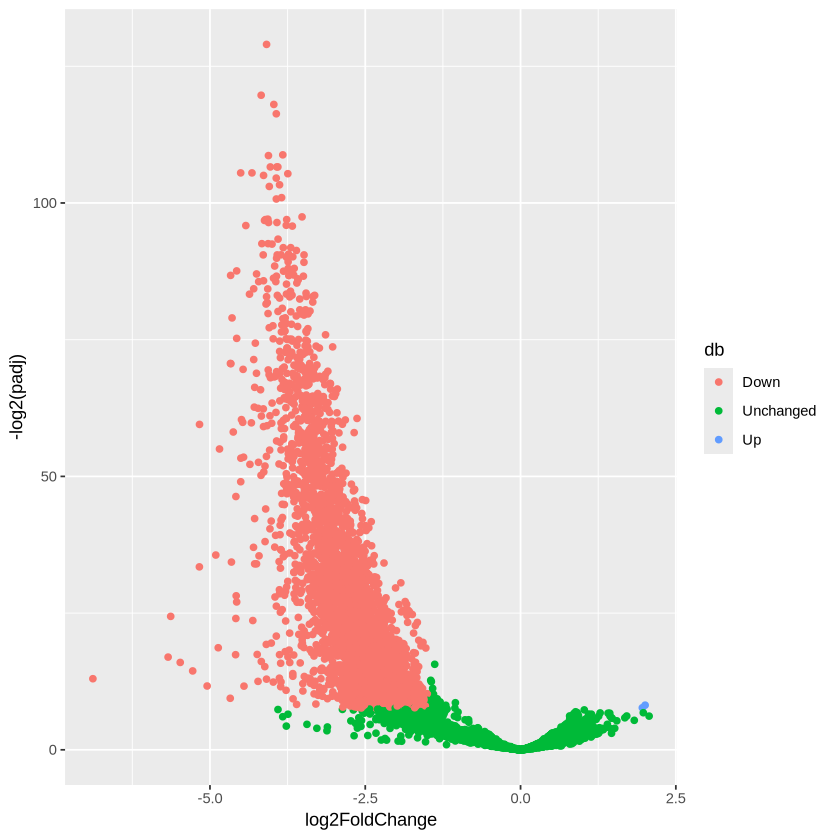

In [6]:
dthrexploration(mva)
mva <- dplot(mva)

In [7]:
rva$comp <- 'rva'
mva$comp <- 'mva'
outpath = "./postdeseq_37/"
write(unlist(rva |> filter(db == "Up") |> select(V1)), paste0(outpath,"rva_up.txt"))
write(unlist(rva |> filter(db == "Down") |> select(V1)), paste0(outpath,"rva_dn.txt"))
write(unlist(mva |> filter(db == "Up") |> select(V1)), paste0(outpath,"mva_up.txt"))
write(unlist(mva |> filter(db == "Down") |> select(V1)), paste0(outpath,"mva_dn.txt"))


allfiles <- rbind(rva,mva)
allfiles$comp<- factor(allfiles$comp,levels = c('mva','rva'))

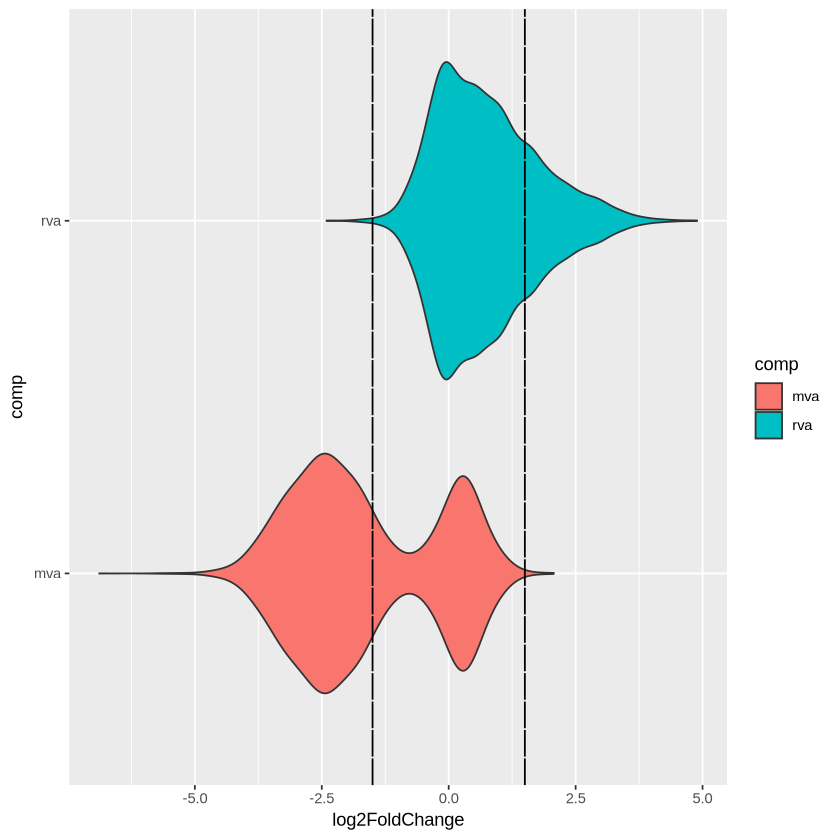

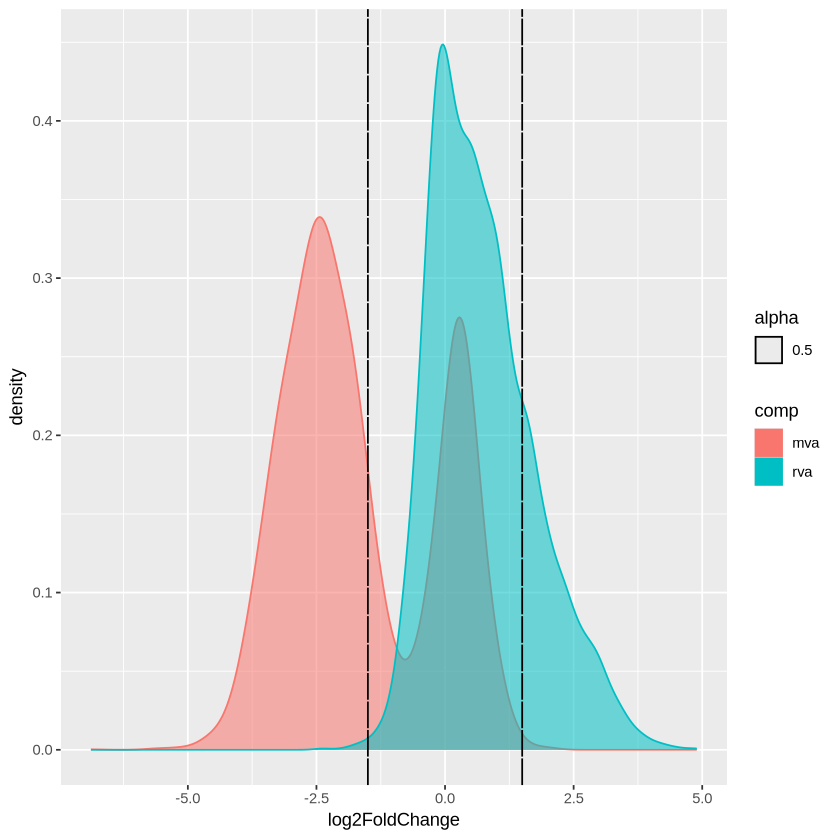

In [8]:
ggplot (allfiles, aes(x= log2FoldChange ,y = comp , fill
                      = comp)) + geom_violin() +
geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
geom_vline(xintercept= FCT, linetype="F1", color = "black") 

ggplot (allfiles, aes(x= log2FoldChange , fill = comp,color = comp, alpha = 0.5 )) + geom_density() +
geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
geom_vline(xintercept= FCT, linetype="F1", color = "black") 

In [9]:
bienPortadosBed <- read_tsv("deseq2_supportFiles_40/mockANDrescueNOTaux_GFP_DESEQNAMES.bed", col_names=F)

Rows: 1200 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): X1, X4
dbl (2): X2, X3

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [10]:
annoPeaks <- read_tsv("deseq2_supportFiles_40/picosReinberg_GFP.tsv", col_names=F)
glimpse(annoPeaks)
allfiles$reinberg <- "-"
for(i in 1:nrow(allfiles)){
    if (allfiles$V1[i] %in% annoPeaks$X4){
            allfiles$reinberg[i] <- unlist(filter(annoPeaks, X4 == allfiles$V1[i])$X13[1]) 
        }
    }

Rows: 47 Columns: 14
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (6): X1, X4, X5, X11, X13, X14
dbl (8): X2, X3, X6, X7, X8, X9, X10, X12

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 47
Columns: 14
$ X1  <chr> "chr2", "chr2", "chr2", "chr2", "chr2", "chr2", "chr6", "chr6", "c…
$ X2  <dbl> 74655991, 74657406, 38338943, 38354657, 38356380, 38351018, 845847…
$ X3  <dbl> 74656396, 74659583, 38340175, 38354906, 38357591, 38351998, 845859…
$ X4  <chr> "mockPeak_3207", "mockPeak_3208", "mockPeak_3155", "mockPeak_3158"…
$ X5  <chr> "Exon (ENSMUST00000001867.12/ENSMUSG00000001815.15, exon 3 of 3)",…
$ X6  <dbl> 2, 2, 2, 2, 2, 2, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, …
$ X7  <dbl> 74655616, 74652991, 38339281, 38353802, 38353802, 38351768, 845714…
$ X8  <dbl> 74659419, 74659557, 38369199, 38360089, 38360089, 38354631, 845876…
$ X9  <dbl> 3804, 6567, 29919, 6288, 6288, 2864, 16267, 16267, 16695, 3743, 87…
$ X10 <dbl> 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, …
$ X11 <chr> "ENSMUST00000173623.1", "ENSMUST00000001867.12", "ENSMUST000001437…
$ X12 <dbl> 3023, 0, 0, 856, 2579, 0, 1775, 0, -408, 0, 93, 475, 208, 484, 0, …
$ X13 <chr> "Evx2",

In [11]:
allfiles <- allfiles |> mutate(peakClass = str_remove(V1,"_.*")) |> mutate(bienPortados = case_when(V1 %in% bienPortadosBed$X4 ~ "Nucleation Dynamic", .default = "Not responsive"))
glimpse(allfiles)

Rows: 12,812
Columns: 14
$ baseMean       <dbl> 38.43330, 34.18115, 65.53570, 43.93990, 119.67458, 155.…
$ log2FoldChange <dbl> 0.327316778, -0.002685664, 1.665154388, 0.583590424, 1.…
$ lfcSE          <dbl> 0.6608281, 0.5913073, 0.5102547, 0.5660258, 0.4604468, …
$ stat           <dbl> 0.49531303, -0.00454191, 3.26337905, 1.03103154, 3.4324…
$ pvalue         <dbl> 6.203792e-01, 9.963761e-01, 1.100922e-03, 3.025260e-01,…
$ padj           <dbl> 8.099395e-01, 9.989093e-01, 5.597337e-03, 5.412351e-01,…
$ V1             <chr> "mockPeak_1", "mockPeak_2", "mockPeak_3", "mockPeak_4",…
$ Significative  <lgl> FALSE, FALSE, FALSE, FALSE, TRUE, TRUE, TRUE, TRUE, TRU…
$ directionality <chr> "UP", "DOWN", "UP", "UP", "UP", "UP", "UP", "UP", "UP",…
$ db             <fct> Unchanged, Unchanged, Unchanged, Unchanged, Up, Up, Up,…
$ comp           <fct> rva, rva, rva, rva, rva, rva, rva, rva, rva, rva, rva, …
$ reinberg       <chr> "-", "-", "-", "-", "-", "-", "-", "-", "-", "-", "-", …
$ peakClass    

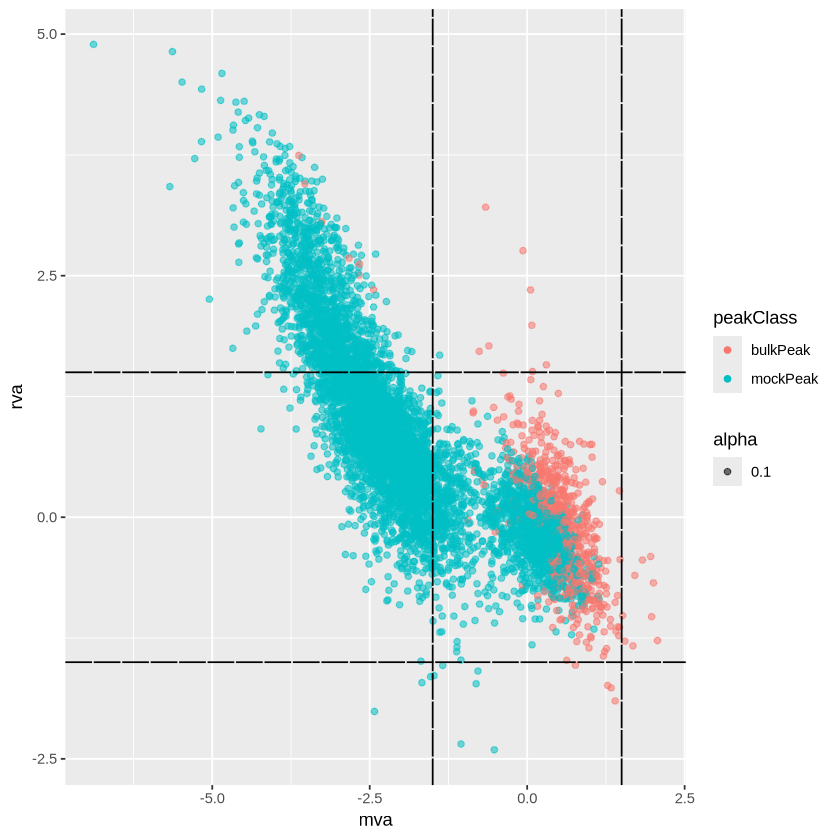

In [12]:
af <- allfiles |> select(V1,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
ggplot (af, aes (y= rva, x = mva, color = peakClass, alpha = 0.1)) + 
    geom_point() + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") 

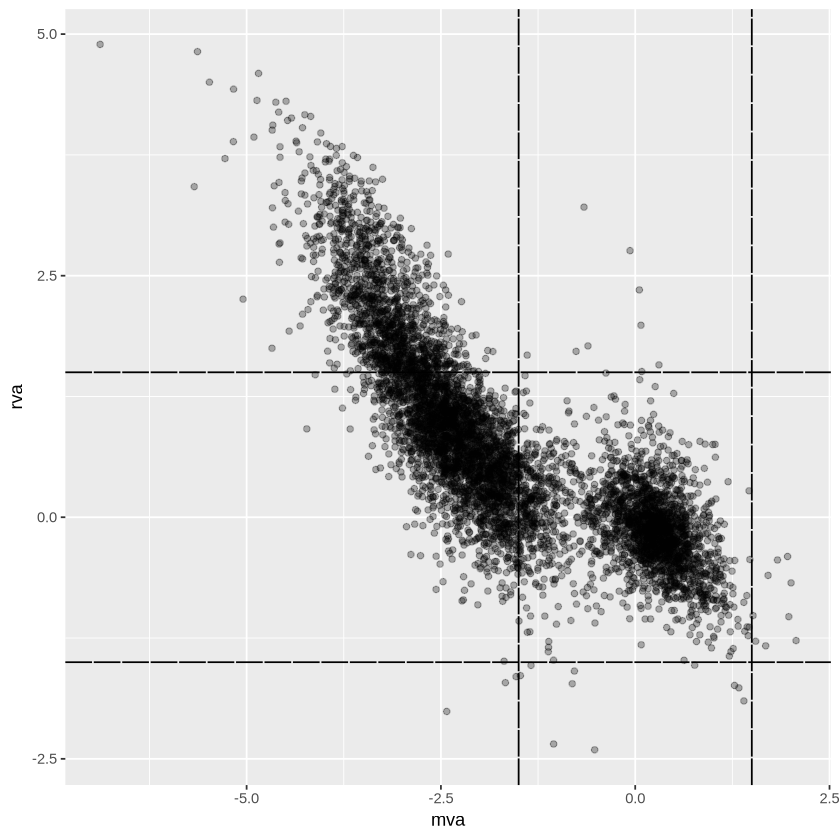

In [13]:
af <- allfiles |> select(V1,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
ggplot (af, aes (y= rva, x = mva)) + 
    geom_point(alpha = 0.3) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") 

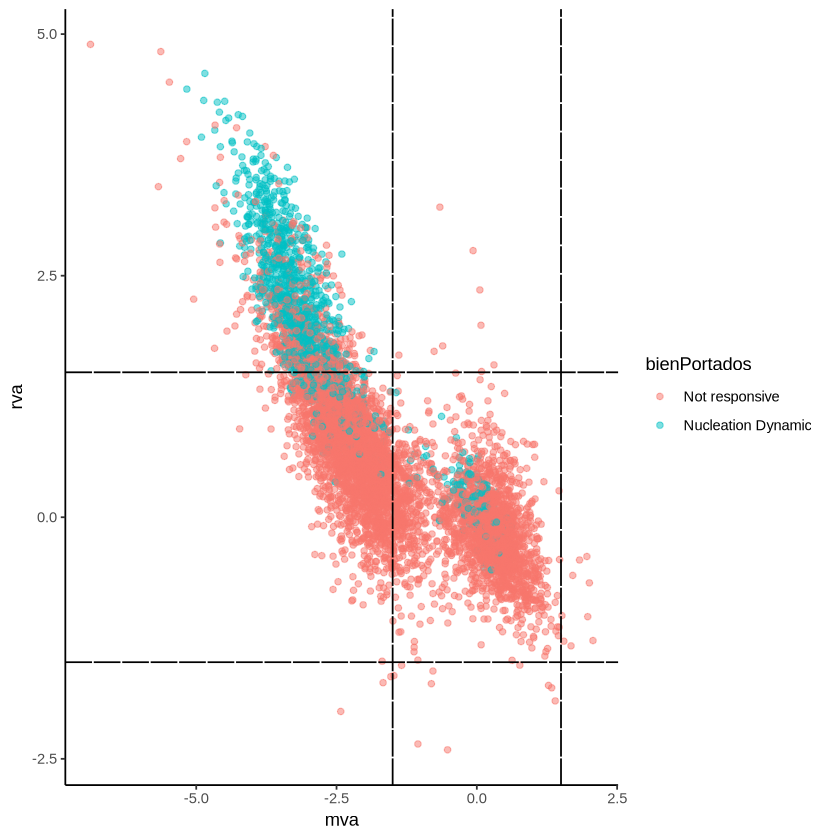

In [14]:
af <- allfiles |> select(V1,bienPortados,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
plt <- ggplot (af, aes (y= rva, x = mva, color = bienPortados)) + 
    geom_point(alpha = 0.5) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") + 
    theme_classic()

plt


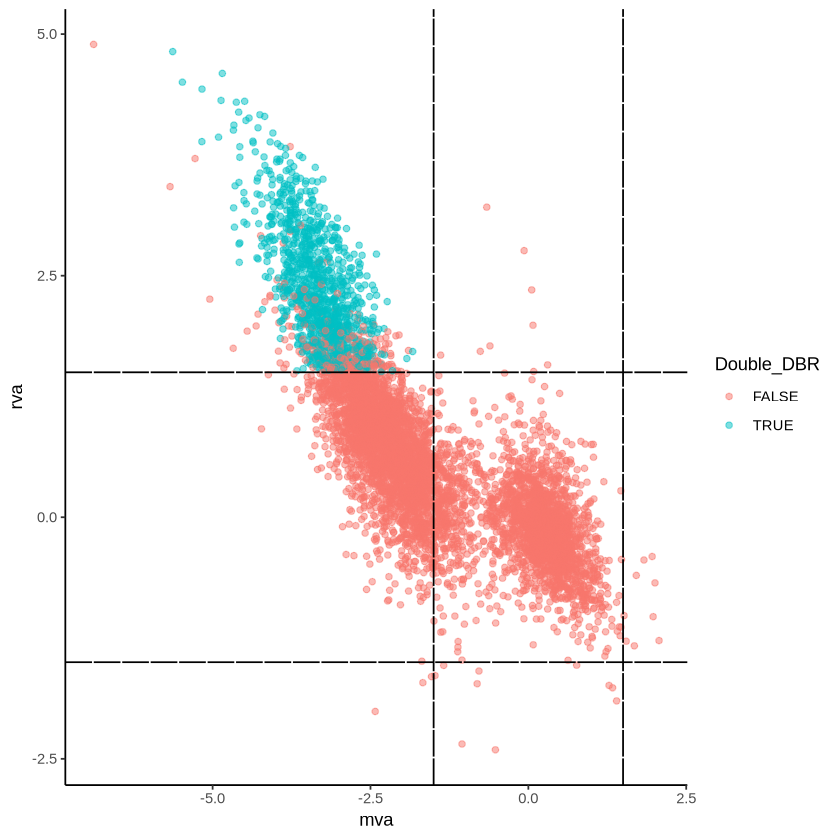

In [15]:
af <- allfiles |> select(V1,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
af$Double_DBR <- sigboth
plt <- ggplot (af, aes (y= rva, x = mva, color = Double_DBR)) + 
    geom_point(alpha = 0.5) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black")  + 
    theme_classic()

plt

ggsave(filename = "/hdd/Itzel/NuevoTodo//plotsJul2025/cuadrantesGFP.pdf", plot = plt, height = 8, width = 8)

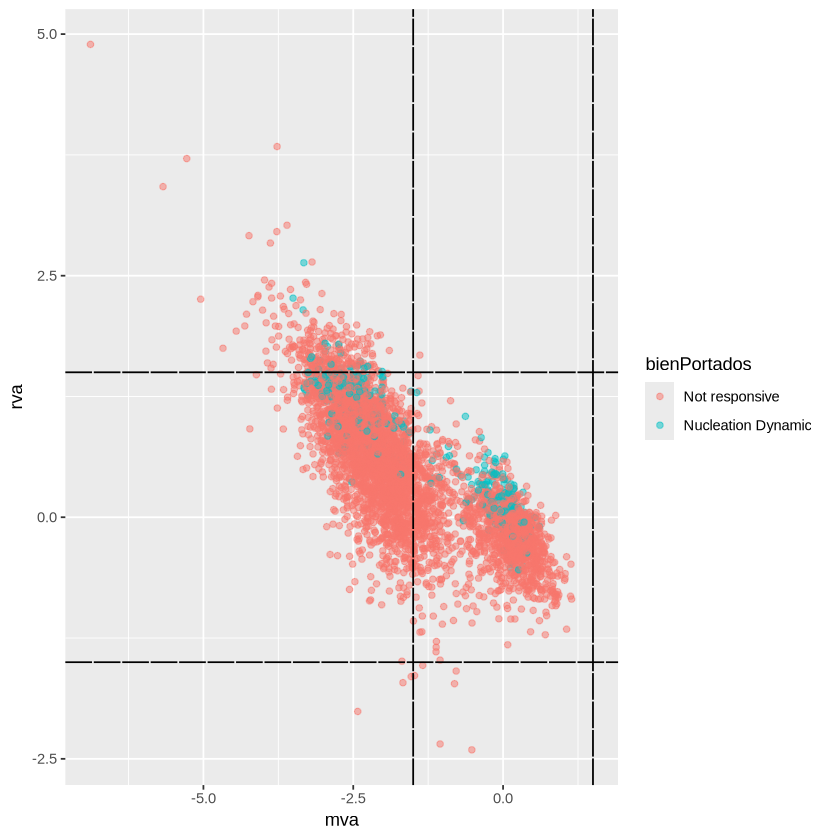

In [16]:
af <- allfiles |> select(V1,bienPortados,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
af$Double_DBR <- sigboth
af <- af |> filter(peakClass == "mockPeak") |> filter(Double_DBR == FALSE)
ggplot (af, aes (y= rva, x = mva, color = bienPortados)) + 
    geom_point(alpha = 0.5) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") 

restoPicosMockNames <- as.vector(unlist(af$V1))

       
        FALSE TRUE
  FALSE  4919  287
  TRUE    387  813

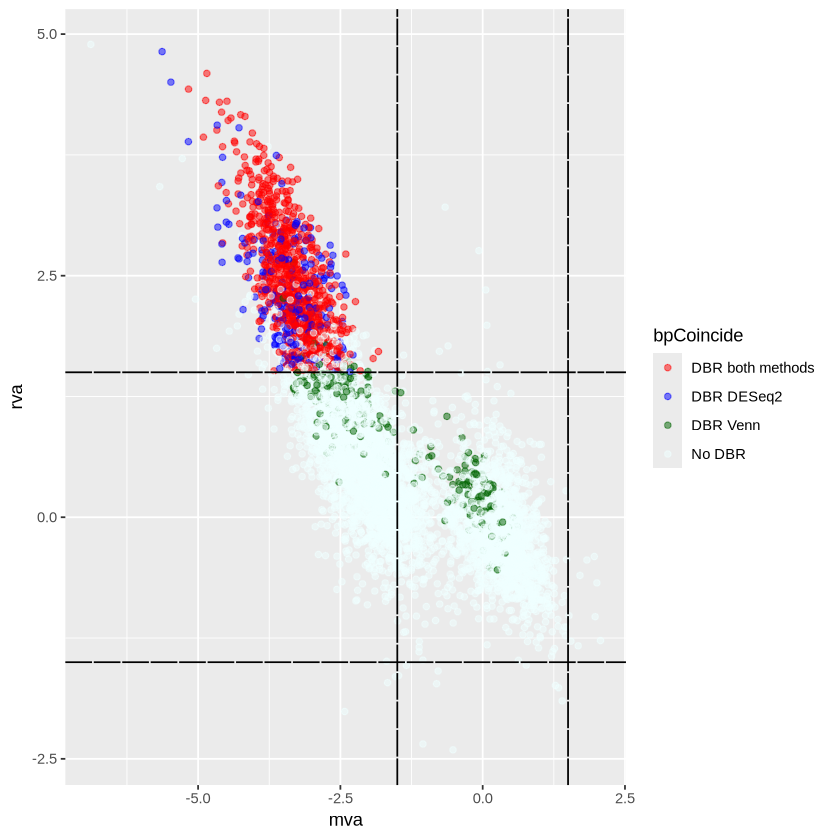

In [17]:
af <- allfiles |> select(V1,peakClass,bienPortados, comp, log2FoldChange) |> mutate(bpbool = case_when(bienPortados == "Not responsive" ~ FALSE, .default = TRUE)) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
af$Double_DBR <- sigboth
af <- af |> mutate(bpCoincide = case_when(bpbool == TRUE & Double_DBR == TRUE ~ "DBR both methods",
                                         bpbool == FALSE & Double_DBR == TRUE ~ "DBR DESeq2",
                                         bpbool == TRUE & Double_DBR == FALSE ~ "DBR Venn",
                                         .default = "No DBR"))
comparacionBienPortados <- table(af$bpbool, af$Double_DBR)
comparacionBienPortados
ggplot (af, aes (y= rva, x = mva, color = bpCoincide)) + 
    geom_point(alpha = 0.5) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=FCT, linetype="F1", color = "black") +
    scale_color_manual(values=c("red", "blue", "darkgreen","azure"))


Attaching package: ‘ggVennDiagram’


The following object is masked from ‘package:tidyr’:

    unite




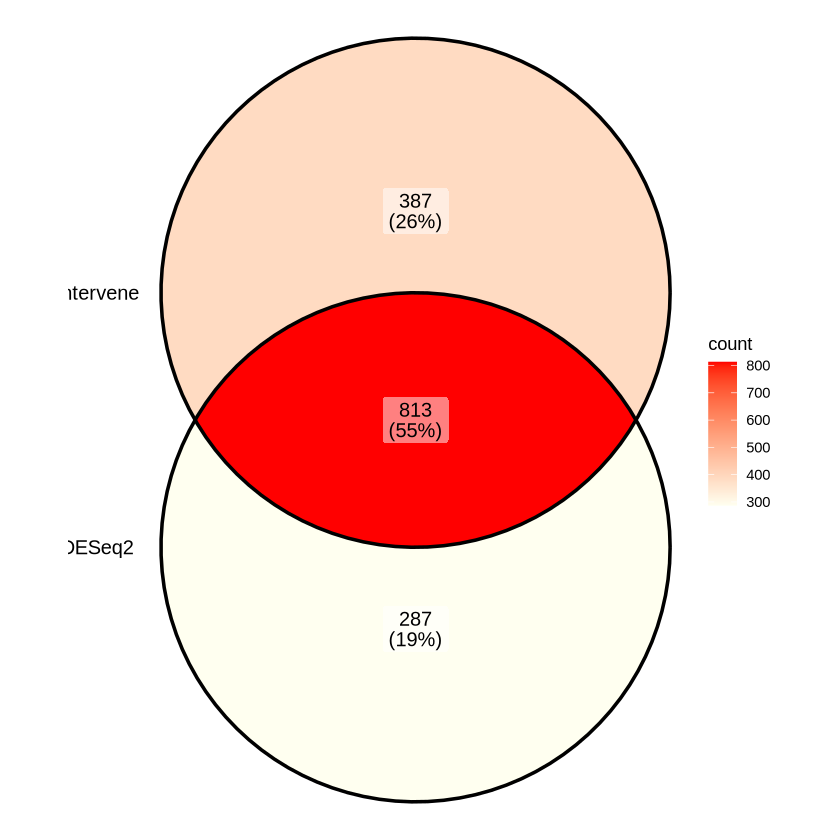

In [18]:
library(ggVennDiagram)
bpdeseq <- unlist(af |> filter(Double_DBR == TRUE) |> select(V1))
bpintervene <- unlist(af |> filter(bpbool == TRUE) |> select(V1))
vlist <- list(DESeq2 = bpdeseq,Intervene = bpintervene)
ggVennDiagram(vlist) + scale_fill_gradient(low = "ivory", high = "red")

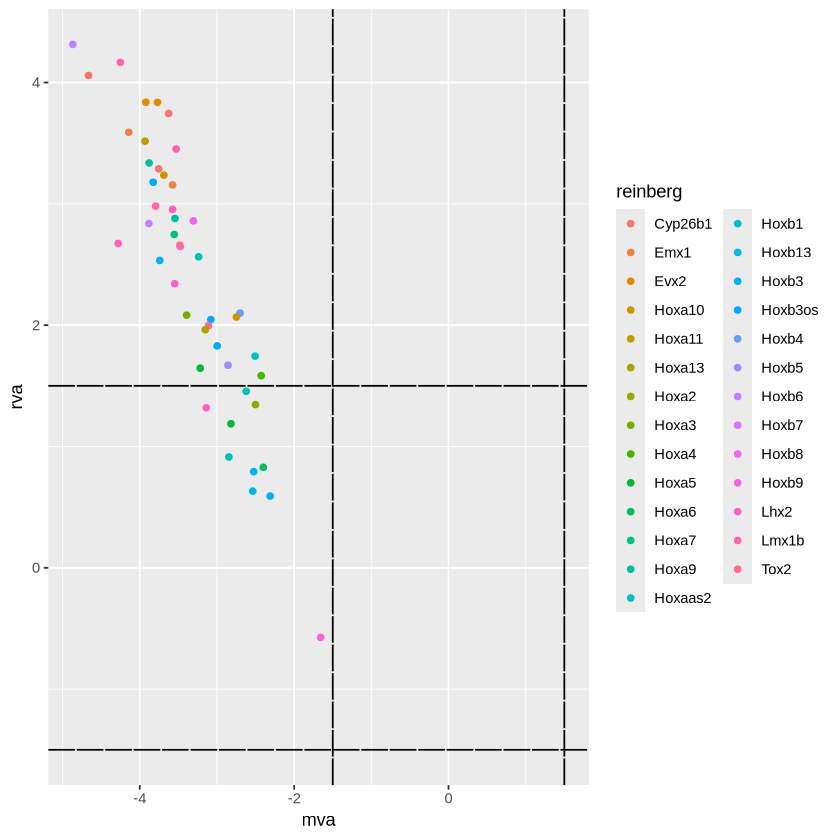

In [19]:
af <- allfiles |> select(V1,reinberg,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange) |> filter(reinberg != "-")
ggplot (af, aes (y= rva, x = mva, color = reinberg, label = reinberg)) + 
    geom_point() + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") 

Warning message:
“Removed 22 rows containing missing values or values outside the scale range (`geom_label()`).”
Warning message:
“Removed 22 rows containing missing values or values outside the scale range (`geom_label()`).”


agg_record_112247565 
                   2

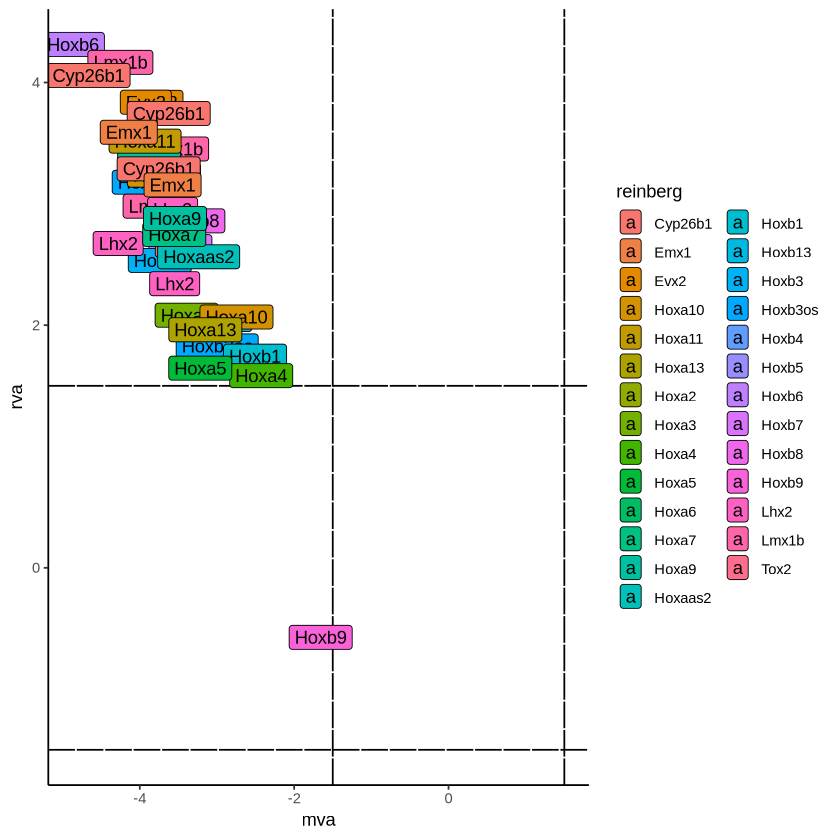

In [20]:
af <- allfiles |> select(V1,Significative,reinberg,peakClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange) |> filter(reinberg != "-")
plt <- ggplot (af, aes (y= rva, x = mva, fill = reinberg, label = reinberg)) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") +
    #geom_text(size =3, aes(color = factor(reinberg)))+
    geom_label() + 
    theme_classic()

plt

pdf("/hdd/Itzel/NuevoTodo/plotsJul2025/cuadrantes_reinberg.pdf", height = 8 ,width = 8)
plt
dev.off()

In [21]:
bpdeseq <-as.vector(bpdeseq)
peakBed <- read_tsv("/hdd/Itzel/NuevoTodo/macs2peaksUnionSet_MockAuxResc_19/allPeaks_GFP.bed", col_names = F)
bpdeseqbed <- peakBed |> filter(X4 %in% bpdeseq)
write_tsv(bpdeseqbed, "/hdd/Itzel/NuevoTodo/bienPortadosDeseq_bed_41/bienPortadosDeseq_GFP.bed", col_names = F)
restomockbed <- peakBed |> filter(X4 %in% restoPicosMockNames)
write_tsv(restomockbed, "/hdd/Itzel/NuevoTodo/bienPortadosDeseq_bed_41/restoPicosMockDeseq_GFP.bed", col_names = F)

Rows: 6458 Columns: 4
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): X1, X4
dbl (2): X2, X3

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [22]:
bpcerca <- read_tsv("./distancias_entre_picos_con_deseq_45/bpcerca.txt", col_names = F)
bplejos <- read_tsv("./distancias_entre_picos_con_deseq_45/bpSoloLejos.txt", col_names = F)
glimpse(allfiles)

Rows: 459 Columns: 1
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): X1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 634 Columns: 1
── Column specification ───────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr (1): X1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 12,812
Columns: 14
$ baseMean       <dbl> 38.43330, 34.18115, 65.53570, 43.93990, 119.67458, 155.…
$ log2FoldChange <dbl> 0.327316778, -0.002685664, 1.665154388, 0.583590424, 1.…
$ lfcSE          <dbl> 0.6608281, 0.5913073, 0.5102547, 0.5660258, 0.4604468, …
$ stat           <dbl> 0.49531303, -0.00454191, 3.26337905, 1.03103154, 3.4324…
$ pvalue         <dbl> 6.203792e-01, 9.963761e-01, 1.100922e-03, 3.025260e-01,…
$ padj           <dbl> 8.099395e-01, 9.989093e-01, 5.597337e-03, 5.412351e-01,…
$ V1             <chr> "mockPeak_1", "mockPeak_2", "mockPeak_3", "mockPeak_4",…
$ Significative  <lgl> FALSE, FALSE, FALSE, FALSE, TRUE, TRUE, TRUE, TRUE, TRU…
$ directionality <chr> "UP", "DOWN", "UP", "UP", "UP", "UP", "UP", "UP", "UP",…
$ db             <fct> Unchanged, Unchanged, Unchanged, Unchanged, Up, Up, Up,…
$ comp           <fct> rva, rva, rva, rva, rva, rva, rva, rva, rva, rva, rva, …
$ reinberg       <chr> "-", "-", "-", "-", "-", "-", "-", "-", "-", "-", "-", …
$ peakClass    

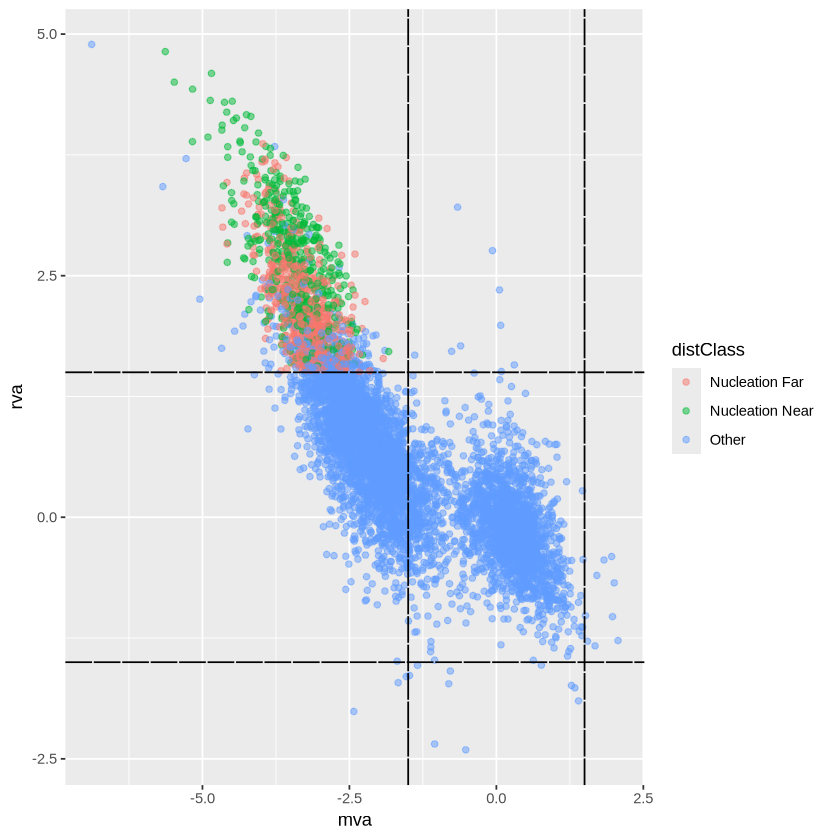

In [23]:
af<- allfiles |> mutate(distClass = case_when(V1 %in% bpcerca$X1 ~ "Nucleation Near",
                                             V1 %in% bplejos$X1 ~ "Nucleation Far",
                                             .default = "Other"))

af <- af |> select(V1,distClass, comp, log2FoldChange) |> pivot_wider(names_from = comp, values_from = log2FoldChange)
af$Double_DBR <- sigboth
ggplot (af, aes (y= rva, x = mva, color = distClass)) + 
    geom_point(alpha = 0.5) + 
    geom_hline(yintercept=-FCT, linetype="F1", color = "black") +
    geom_hline(yintercept= FCT, linetype="F1", color = "black") +
    geom_vline(xintercept=-FCT, linetype="F1", color = "black") +
    geom_vline(xintercept= FCT, linetype="F1", color = "black") 